In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import time
import pickle
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib.ticker as ticker

from f_compare_bn import * 
from f_recog_prior_norm_plot import plot_z_white_fig4_style

# global var
S0 = 1.0
K = 1.0
r = 0.03
sigma = np.sqrt(0.05)
T = 1.5
BS_eta = (S0, K, r, sigma, T)
# S0, K, r, kappa, theta, xi, rho, Y0, T = Hes_eta
Hes_eta = (S0, K, r, 2, 0.05, 0.5, -0.7, 0.05, T)

B = 0.8 # down-and-out must B < S0 and B < K
model_type = 'bs' # hes or bs
barr_type = 'van' # van or barr
opt_type = 'call' # call or put
chunk_dir = f"/mnt/d/bs_chunks_correction/" if model_type == 'bs' else f"/mnt/d/hes_chunks_correction/"
eta_path = "/mnt/d/bs_eta_basic.h5" if model_type == 'bs' else "/mnt/d/hes_eta_basic.h5"

if not((B < S0) & (B < K)):
    raise ValueError("down-and-out : B should be smaller than S0 and K")

if not(opt_type == 'call' or  opt_type == 'put'):
    raise ValueError("option_type must be 'call' or 'put'")

if not(barr_type == 'van' or  barr_type == 'barr'):
    raise ValueError("barr_type must be 'van' or 'barr'")

if not(model_type == 'hes' or  model_type == 'bs'):
    raise ValueError("model_type must be 'hes' or 'bs'")

if not(torch.cuda.is_available()):
    raise ValueError("CUDA is not available")
device = torch.device("cuda")

bs_stats = {
    "x_mean": -0.1045446063,
    "x_std": 0.6455563393,
    "m_mean": -0.4579059199,
    "m_std": 0.5553496410
}

if model_type == 'hes':
    if barr_type == 'barr':
        if opt_type == 'call':
            bench_price = 0.115733
        else: # put
            bench_price = 0.005170
    else: # van
        if opt_type == 'call':
            bench_price = 0.124491
        else: # put
            bench_price = 0.080488

elif model_type == 'bs':
    if barr_type == 'barr':
        if opt_type == 'call':
            bench_price = 0.123493
        else: # put
            bench_price = 0.009535
    else: # van
        if opt_type == 'call':
            bench_price = 0.129944
        else: # put
            bench_price = 0.085942

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# CVAE training settings
dim_z       = 4 # 8, 12
hidden_dims = [128, 128, 64] # [128, 128, 64], [256, 256, 128], [512, 512, 256]
batch_size  = 4096 # 1024, 2048, 4096, 8192
bn_chunks   = 5 # None or num
use_bn      = True if bn_chunks is not None else False
lr          = 1e-4 # 1e-3, 1e-4, 1e-5, 1e-6
beta        = 1
warmup_chunks = None # None or num
num_chunks  = 5
validation_chunk_idxs = [15,24,78]
val_every_chunks = 1
resume_path = None # or None 이어서 학습하고 싶을 때
save_path   = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk194.pt"

n_samples = 10000 # n_samples= 1k, 10k, 100k
if n_samples % 2 != 0:
    raise ValueError("n_samples should be an even number for antithetic sampling")

if model_type == 'hes':
    test_etas = [0.03, 2.0,  0.05, 0.5, -0.7, 0.05, 1.5]
    eta_keys  = ['r', 'lambda', 'v_bar', 'xi', 'rho', 'Y0', 'T']
else: # model_type = 'bs'
    test_etas = [r, sigma, T]
    eta_keys  = ['r', 'sigma', 'T']

# Loss history

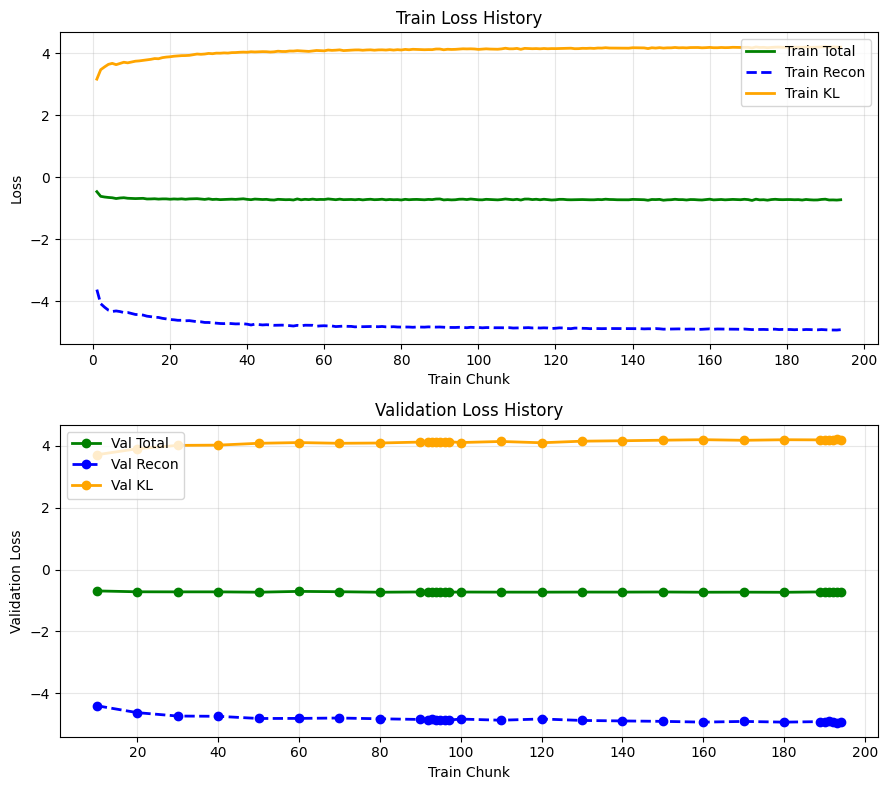

In [3]:
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)

if chunk_loss_history is None:
    raise ValueError("checkpoint에 chunk_loss_history가 없습니다.")

train_chunks = np.arange(1, len(chunk_loss_history["total_loss"]) + 1)
val_chunks = np.asarray(chunk_loss_history.get("val_global_chunk", []), dtype=int)
has_val = len(val_chunks) > 0

n_rows = 2 if has_val else 1
fig, axes = plt.subplots(n_rows, 1, figsize=(9, 4 * n_rows), sharex=False)
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

# train loss history
ax = axes[0]
ax.plot(train_chunks, chunk_loss_history["total_loss"], label="Train Total", color="green", linewidth=2)
ax.plot(train_chunks, chunk_loss_history["recon_loss"], label="Train Recon", color="blue", linestyle="--", linewidth=2)
ax.plot(train_chunks, chunk_loss_history["KL_loss"], label="Train KL", color="orange", linewidth=2)
ax.set_xlabel("Train Chunk")
ax.set_ylabel("Loss")
ax.set_title("Train Loss History")
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.legend()
ax.grid(True, alpha=0.3)

# validation loss history
if has_val:
    ax = axes[1]
    ax.plot(val_chunks, chunk_loss_history["val_total_loss"], marker="o", label="Val Total", color="green", linewidth=2)
    ax.plot(val_chunks, chunk_loss_history["val_recon_loss"], marker="o", label="Val Recon", color="blue", linestyle="--", linewidth=2)
    ax.plot(val_chunks, chunk_loss_history["val_KL_loss"], marker="o", label="Val KL", color="orange", linewidth=2)
    ax.set_xlabel("Train Chunk")
    ax.set_ylabel("Validation Loss")
    ax.set_title("Validation Loss History")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.legend()
    ax.grid(True, alpha=0.3)
else:
    print("validation loss history가 없습니다. validation_chunk_idxs를 넣고 학습한 checkpoint인지 확인하세요.")

plt.tight_layout()
plt.show()


In [60]:
# loss history
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)
chunk_indices = ckpt["chunk_loss_history"]["chunk_idx"]

for i in range(len(chunk_loss_history["total_loss"])):
    print(f"Num : {chunk_loss_history['global_chunk'][i]}, Idx : {chunk_indices[i]}, Total Loss: {chunk_loss_history['total_loss'][i]:.4f}, Recon Loss: {chunk_loss_history['recon_loss'][i]:.4f}, KL Loss: {chunk_loss_history['KL_loss'][i]:.4f}")

Num : 0, Idx : 88, Total Loss: -0.4710, Recon Loss: -3.6298, KL Loss: 3.1588
Num : 1, Idx : 8, Total Loss: -0.6216, Recon Loss: -4.0848, KL Loss: 3.4632
Num : 2, Idx : 75, Total Loss: -0.6431, Recon Loss: -4.1968, KL Loss: 3.5537
Num : 3, Idx : 41, Total Loss: -0.6575, Recon Loss: -4.2929, KL Loss: 3.6354
Num : 4, Idx : 17, Total Loss: -0.6674, Recon Loss: -4.3351, KL Loss: 3.6677
Num : 5, Idx : 66, Total Loss: -0.6924, Recon Loss: -4.3181, KL Loss: 3.6256
Num : 6, Idx : 57, Total Loss: -0.6746, Recon Loss: -4.3375, KL Loss: 3.6629
Num : 7, Idx : 31, Total Loss: -0.6662, Recon Loss: -4.3696, KL Loss: 3.7035
Num : 8, Idx : 58, Total Loss: -0.6834, Recon Loss: -4.3679, KL Loss: 3.6845
Num : 9, Idx : 87, Total Loss: -0.6874, Recon Loss: -4.4002, KL Loss: 3.7128
Num : 10, Idx : 45, Total Loss: -0.6939, Recon Loss: -4.4314, KL Loss: 3.7375
Num : 11, Idx : 65, Total Loss: -0.6898, Recon Loss: -4.4374, KL Loss: 3.7475
Num : 12, Idx : 97, Total Loss: -0.6860, Recon Loss: -4.4513, KL Loss: 3.76

In [44]:
# validation dim-z KL mean value
ckpt = torch.load(save_path, map_location=device, weights_only=False)
chunk_loss_history = ckpt.get("chunk_loss_history", None)

if chunk_loss_history is None:
    raise ValueError("checkpoint에 chunk_loss_history가 없습니다.")

val_chunks = chunk_loss_history.get("val_global_chunk", [])
val_kl_dim_mean = chunk_loss_history.get("val_kl_dim_mean", [])

if len(val_chunks) == 0 or len(val_kl_dim_mean) == 0:
    raise ValueError("validation KL dim 기록이 없습니다. validation_chunk_idxs를 넣고 학습한 checkpoint인지 확인하세요.")

for i in range(len(val_chunks)):
    kl_by_dim = val_kl_dim_mean[i]
    kl_text = " | ".join([f"z{j}: {v:.6f}" for j, v in enumerate(kl_by_dim)])
    print(f"Num : {val_chunks[i]}, {kl_text}")


Num : 10, z0: 0.000070 | z1: 0.000104 | z2: 1.174014 | z3: 2.539242
Num : 20, z0: 0.000050 | z1: 0.000069 | z2: 1.276893 | z3: 2.630934
Num : 30, z0: 0.000032 | z1: 0.000040 | z2: 1.345787 | z3: 2.670247
Num : 40, z0: 0.000019 | z1: 0.000022 | z2: 1.345057 | z3: 2.679455
Num : 50, z0: 0.000016 | z1: 0.000014 | z2: 1.375927 | z3: 2.708216
Num : 60, z0: 0.001720 | z1: 0.000601 | z2: 1.390500 | z3: 2.714489
Num : 70, z0: 0.000009 | z1: 0.000007 | z2: 1.379680 | z3: 2.704577
Num : 80, z0: 0.000009 | z1: 0.000007 | z2: 1.386772 | z3: 2.706357
Num : 90, z0: 0.000010 | z1: 0.000008 | z2: 1.401061 | z3: 2.722387
Num : 92, z0: 0.000009 | z1: 0.000012 | z2: 1.397926 | z3: 2.722866
Num : 93, z0: 0.000012 | z1: 0.000007 | z2: 1.400104 | z3: 2.725624
Num : 94, z0: 0.000006 | z1: 0.000007 | z2: 1.407682 | z3: 2.733403
Num : 95, z0: 0.000006 | z1: 0.000006 | z2: 1.407715 | z3: 2.723949
Num : 96, z0: 0.000007 | z1: 0.000006 | z2: 1.404914 | z3: 2.734683
Num : 97, z0: 0.000007 | z1: 0.000007 | z2: 1.40

# inference result

In [18]:
cvae_result_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}_{barr_type}_{opt_type}.pkl"

ckpt = torch.load(save_path, map_location=device, weights_only=False)

cvae = CVAE(
    dim_x=ckpt["dim_x"],
    dim_eta=ckpt["dim_eta"],
    dim_z=ckpt["dim_z"],
    hidden_dims=ckpt["hidden_dims"],
    use_bn=ckpt.get("use_bn", False),
).to(device)

state_dict = ckpt["model_state"]
if any(k.startswith("module.") for k in state_dict):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

cvae.load_state_dict(state_dict)
cvae.eval()

eta_raw = np.array(test_etas, dtype=np.float32)
eta_scaled = (eta_raw - ckpt["eta_min"]) / (ckpt["eta_max"] - ckpt["eta_min"] + 1e-8)
eta_t = torch.tensor(eta_scaled, dtype=torch.float32, device=device)

n_list = [1000, 10000, 100000]
n_repeats = 50
results = {n: [] for n in n_list}


for n in n_list:
    for _ in range(n_repeats):
        if barr_type == "barr":
            price = cvae.price_barrier(eta_t, B, K, r, T, opt_type, n)
        else:
            price = cvae.price_vanilla(eta_t, K, r, T, opt_type, n)
        results[n].append(price)

with open(cvae_result_path, "wb") as f:
    pickle.dump(results, f)

CVAE
n=  1000 | mean=0.11878633 | 95% CI=±0.01179804 | error=-3.81%
n= 10000 | mean=0.11955055 | 95% CI=±0.00387205 | error=-3.19%
n=100000 | mean=0.11961764 | 95% CI=±0.00119104 | error=-3.14%


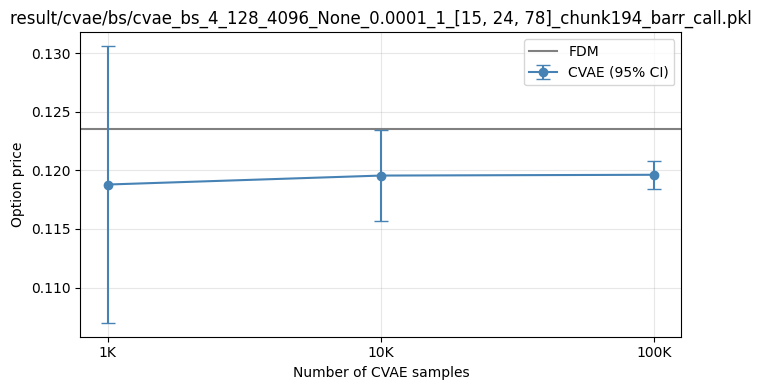

In [19]:
# 공용 그래프: CVAE inference 결과만 표시
n_list = [1000, 10000, 100000]
cvae_result_path = f"result/cvae/{model_type}/cvae_{model_type}_{dim_z}_{hidden_dims[0]}\
_{batch_size}_{bn_chunks}_{lr}_{beta}_{validation_chunk_idxs}_chunk{num_chunks}_{barr_type}_{opt_type}.pkl"

with open(cvae_result_path, "rb") as f:
    results = pickle.load(f)

means = np.array([np.mean(results[n]) for n in n_list])
stds = np.array([np.std(results[n]) for n in n_list])
ci = 1.96 * stds

print("CVAE")
for n, mean, err in zip(n_list, means, ci):
    rel_err = (mean - bench_price) / (bench_price + 1e-12) * 100
    print(f"n={n:6d} | mean={mean:.8f} | 95% CI=±{err:.8f} | error={rel_err:+.2f}%")

plt.figure(figsize=(7, 4))
plt.axhline(bench_price, color="gray", linewidth=1.5, label="FDM")
plt.errorbar(
    range(len(n_list)), means,
    yerr=ci, fmt="o-", color="steelblue", capsize=5, label="CVAE (95% CI)",
)
plt.xticks(range(len(n_list)), ["1K", "10K", "100K"])
plt.xlabel("Number of CVAE samples")
plt.ylabel("Option price")
plt.title(f"{cvae_result_path}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()